In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import expon, chi2

In [29]:
class DataStreamProcessor:
    def __init__(self, file_path: str):
        self.intervals = self.load_intervals(file_path)
        self.rate = None

    @staticmethod
    def load_intervals(file_path: str) -> np.array:
        with open(file_path, 'r') as f:
            interval_data = f.read().replace('\n', ' ')
            interval_data = list(map(int, interval_data.split(' ')))
        return np.array(interval_data)

    def display_table_and_graph(self):
        data_table = pd.DataFrame({"Intervals": self.intervals})
        print(data_table)
        plt.figure(figsize=(10, 5))
        plt.plot(range(1, len(self.intervals) + 1), self.intervals, marker='o')
        plt.title("Intervals Between Events")
        plt.xlabel("Index")
        plt.ylabel("Interval")
        plt.grid()
        plt.show()

    def test_exponential_distribution(self):
        _, bins, _ = plt.hist(self.intervals, bins='auto', density=True, alpha=0.7, label="Data")
        lambda_est = 1 / np.mean(self.intervals)
        x = np.linspace(min(self.intervals), max(self.intervals), 100)
        plt.plot(x, expon.pdf(x, scale=1 / lambda_est), label=f"Exp Fit (\u03bb={lambda_est:.4f})")
        plt.title("Exponential Fit")
        plt.xlabel("Interval")
        plt.ylabel("Density")
        plt.legend()
        plt.grid()
        plt.show()

        mean = np.mean(self.intervals)
        variance = np.var(self.intervals)
        chi2_stat = sum(((self.intervals - mean) ** 2) / variance)
        p_value = chi2.sf(chi2_stat, len(self.intervals) - 1)
        return lambda_est, p_value

    def check_trend(self):
        trend = np.polyfit(range(len(self.intervals)), self.intervals, 1)
        plt.figure(figsize=(10, 5))
        plt.plot(self.intervals, marker='o', label="Data")
        plt.plot(np.polyval(trend, range(len(self.intervals))), label=f"Trend: y={trend[0]:.2f}x + {trend[1]:.2f}")
        plt.title("Trend Analysis")
        plt.xlabel("Index")
        plt.ylabel("Interval")
        plt.legend()
        plt.grid()
        plt.show()

        return trend

    def calculate_rate_and_confidence(self):
        rate = 1 / np.mean(self.intervals)
        std_dev = np.std(self.intervals) / np.sqrt(len(self.intervals))
        conf_interval = (rate - 1.96 * std_dev, rate + 1.96 * std_dev)
        self.rate = rate
        return rate, conf_interval

    def piecewise_constant_rate(self, num_classes):
        bins = np.linspace(min(self.intervals), max(self.intervals), num_classes + 1)
        rates = []
        for i in range(len(bins) - 1):
            class_intervals = self.intervals[(self.intervals >= bins[i]) & (self.intervals < bins[i + 1])]
            rates.append(len(class_intervals) / (bins[i + 1] - bins[i]))
        plt.figure(figsize=(10, 5))
        plt.step(bins[:-1], rates, where='post', label="Piecewise Constant Rate")
        plt.title("Piecewise Constant Rate")
        plt.xlabel("Interval")
        plt.ylabel("Rate")
        plt.grid()
        plt.show()
        return bins, rates

    def continuous_intensity_function(self):
        def model(t, a, b):
            return a + b * t

        t = np.linspace(0, max(self.intervals), len(self.intervals))
        params, _ = curve_fit(model, t, self.intervals)
        plt.figure(figsize=(10, 5))
        plt.plot(t, model(t, *params), label=f"\u03bb(t) = {params[0]:.2f} + {params[1]:.2f}t")
        plt.scatter(t, self.intervals, alpha=0.7, label="Data")
        plt.title("Continuous Intensity Function")
        plt.xlabel("Time")
        plt.ylabel("Intensity")
        plt.legend()
        plt.grid()
        plt.show()
        return params

    def compare_poisson_streams(self, other_intervals):
        combined = np.concatenate((self.intervals, other_intervals))
        stat, p_value = chi2.sf(sum((combined - np.mean(combined)) ** 2 / np.var(combined)), len(combined) - 1)
        return stat, p_value


     Intervals
0            5
1            6
2            3
3            2
4            5
..         ...
249         25
250         25
251         21
252         19
253         18

[254 rows x 1 columns]


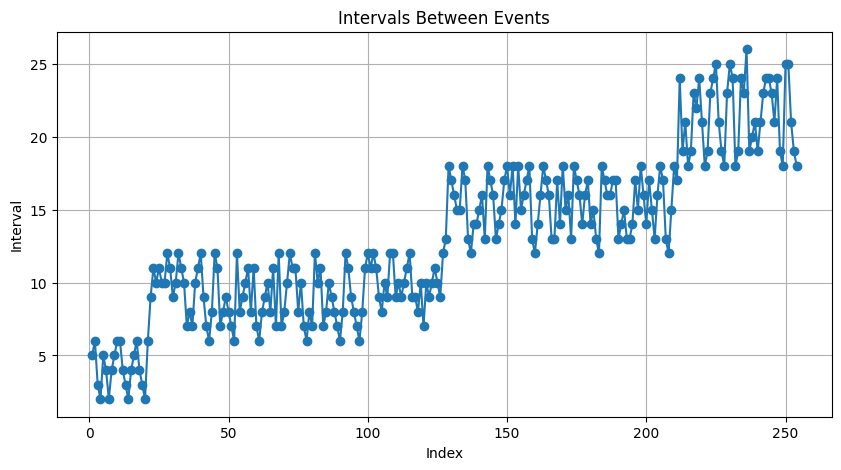

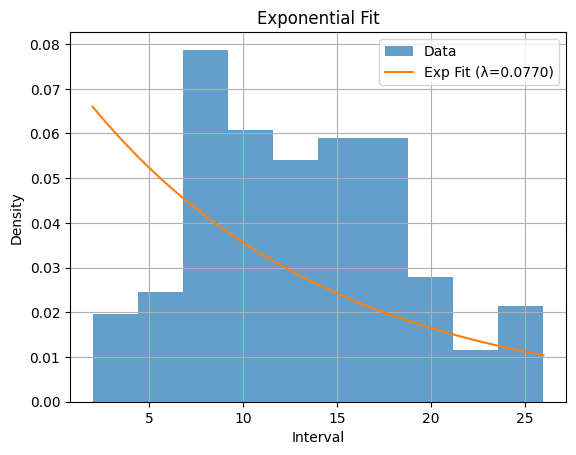

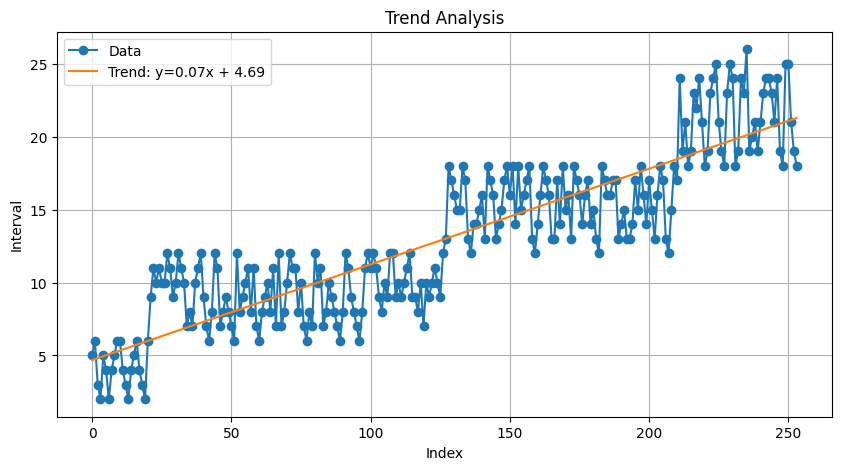

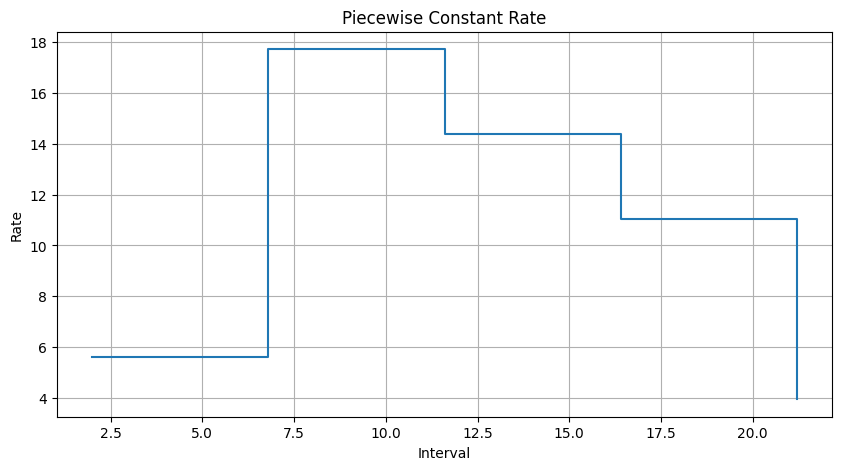

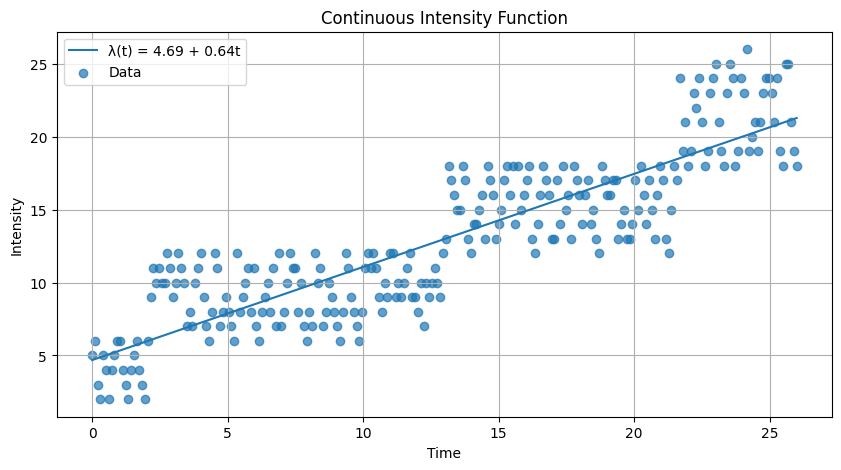

In [30]:
processor = DataStreamProcessor(file_path="intervals.txt")
processor.display_table_and_graph()
lambda_est, p_value = processor.test_exponential_distribution()
trend = processor.check_trend()
rate, conf_interval = processor.calculate_rate_and_confidence()
bins, rates = processor.piecewise_constant_rate(5)
params = processor.continuous_intensity_function()
